<a id="toc"></a>
# **Predicting Irrigation Need: Ensemble Meta-Stacking**

Table of Contents:
- [About the Project](#1)
- [About the Data](#2)
- [Set Up](#3)
- [Exploratory Data Analysis](#4)
    - [Training Data Overview](#4.1)
    - [Testing Data Overview](#4.2)
    - [Target Variable: Irrigation Need](#4.3)
    - [Numerical Features](#4.4)
    - [Categorical Features](#4.5)
    - [Feature Interactions](#4.6)
- [Adversarial Validation](#5)
- [Data Cleaning & Preprocessing](#6)
    - [Combining the Data](#6.1)
    - [Feature Engineering](#6.2)
    - [Encoding](#6.3)
- [Modeling: Ensemble Meta-Stacking](#7)
    - [Baseline Model](#7.1)
    - [Model Configuration](#7.2)
- [Training & Evaluation](#8)
- [Predictions & Submission](#9)
- [Discussion](#10)
- [References](#ref)

<a id="toc"></a>  <a href="#2" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="1"></a>
# **1) About the Project**

This project has been completed as part of [Kaggle's Predicting Irrigation Need Competition](https://www.kaggle.com/competitions/playground-series-s6e4).

**Objective:** Predict the irrigation need - classified as **Low**, **Medium**, or **High** - for a given agricultural field based on a set of soil, weather, crop, and field management features. This is a **multi-class classification** problem.

**Model:** We will build an **ensemble meta-stacking classifier** combining three gradient boosting frameworks: LightGBM, XGBoost, and CatBoost. Each model is trained via 5-fold stratified cross-validation to produce out-of-fold (OOF) probability predictions. A Logistic Regression meta-learner then combines these stacked predictions to make the final classification. This two-level architecture exploits the structural differences between the three boosting algorithms to achieve higher predictive accuracy than any single model alone.

**Evaluation Metric:** Submissions are evaluated using **Balanced Accuracy**, which computes accuracy for each class independently and then averages those per-class rates. Unlike standard accuracy, balanced accuracy gives equal weight to all three classes regardless of their frequency in the dataset, making it well-suited for the imbalanced distribution observed here.

<a id="toc"></a>  <a href="#1" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#3" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="2"></a>
# **2) About the Data**

The datasets provided in this competition were generated from a deep learning model trained on the original [Irrigation Prediction dataset](https://www.kaggle.com/datasets/nelakurthisudheer/irrigation-prediction) available on Kaggle. While the data is synthetically generated, it closely mimics the statistical properties of the source material.

Three datasets are used throughout this project:
- **Train (`train.csv`)**: 630,000 rows; 19 feature columns + 1 target column (`Irrigation_Need`)
- **Test (`test.csv`)**: 270,000 rows; 19 feature columns (no target)
- **Original (`irrigation_prediction.csv`)**: 10,000 rows; real-world data used as a supplement

**Feature Descriptions:**

| Feature | Type | Description |
|---|---|---|
| `Soil_Type` | Categorical | Type of soil (Loamy, Clay, Sandy, Silt) |
| `Soil_pH` | Numerical | pH level of the soil (4.8 - 8.2) |
| `Soil_Moisture` | Numerical | Volumetric soil moisture (%) |
| `Organic_Carbon` | Numerical | Organic carbon content of soil (%) |
| `Electrical_Conductivity` | Numerical | Soil salinity proxy (dS/m) |
| `Temperature_C` | Numerical | Ambient temperature (°C) |
| `Humidity` | Numerical | Relative humidity (%) |
| `Rainfall_mm` | Numerical | Annual rainfall (mm) |
| `Sunlight_Hours` | Numerical | Daily sunlight hours |
| `Wind_Speed_kmh` | Numerical | Wind speed (km/h) |
| `Crop_Type` | Categorical | Type of crop (Sugarcane, Wheat, Rice, etc.) |
| `Crop_Growth_Stage` | Categorical | Growth stage (Sowing, Vegetative, Flowering, Harvest) |
| `Season` | Categorical | Agricultural season (Rabi, Kharif, Zaid) |
| `Irrigation_Type` | Categorical | Irrigation method (Drip, Canal, Sprinkler, Rainfed) |
| `Water_Source` | Categorical | Source of water (River, Reservoir, Rainwater, Groundwater) |
| `Field_Area_hectare` | Numerical | Field area (hectares) |
| `Mulching_Used` | Categorical | Whether mulching was applied (Yes/No) |
| `Previous_Irrigation_mm` | Numerical | Amount of irrigation applied in previous cycle (mm) |
| `Region` | Categorical | Geographic region (North, South, East, West, Central) |

**Target Variable:** `Irrigation_Need` - one of three ordinal classes: **Low**, **Medium**, **High**

<a id="toc"></a>  <a href="#2" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#4" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="3"></a>
# **3) Set Up**

In [ ]:
# Importing and loading necessary libraries and packages
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white', palette='Set2')

import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading in the datasets
df_train    = pd.read_csv('/Users/conradkleykamp/Documents/Predicting-Irrigation-Need/data/train.csv')
df_test     = pd.read_csv('/Users/conradkleykamp/Documents/Predicting-Irrigation-Need/data/test.csv')
df_original = pd.read_csv('/Users/conradkleykamp/Documents/Predicting-Irrigation-Need/data/irrigation_prediction.csv')

<a id="toc"></a>  <a href="#3" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#5" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="4"></a>
# **4) Exploratory Data Analysis**

<a id="toc"></a>
<a id="4.1"></a>
## **4.1) Training Data Overview**

In [3]:
# Viewing first 5 entries of 'df_train'
df_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
# Creating a function to show a summary of a given dataset
def show_sum(df):
    sum_df = pd.DataFrame(index=list(df))
    sum_df['Dtype']    = df.dtypes
    sum_df['Count']    = df.count()
    sum_df['#Unique']  = df.nunique()
    sum_df['#Missing'] = df.isnull().sum()
    sum_df['%Missing'] = (df.isnull().sum() / len(df) * 100).round(2)
    return sum_df

In [5]:
# Examining summary of 'df_train'
show_sum(df_train)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,630000,630000,0,0.0
Soil_Type,object,630000,4,0,0.0
Soil_pH,float64,630000,341,0,0.0
Soil_Moisture,float64,630000,5223,0,0.0
Organic_Carbon,float64,630000,131,0,0.0
Electrical_Conductivity,float64,630000,341,0,0.0
Temperature_C,float64,630000,2934,0,0.0
Humidity,float64,630000,6475,0,0.0
Rainfall_mm,float64,630000,19308,0,0.0
Sunlight_Hours,float64,630000,701,0,0.0


In [6]:
# Examining summary statistics of each column in 'df_train'
df_train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


**OBSERVATIONS: 'df_train'**
- Shape of the data:
    - 630,000 (rows), 21 (columns)
- Includes target variable `Irrigation_Need`
- Column types:
    - Float64 (8 numerical columns)
    - Int64 (1 column: `id`)
    - Object (8 categorical columns + 1 target column)
- No missing values across any column

**Summary Statistics: 'df_train'**

- **Soil_pH**: Mean: **6.48**; Range: 4.80 - 8.20 (slightly acidic to slightly alkaline)
- **Soil_Moisture**: Mean: **37.3%**; Range: 8.0 - 65.0 (wide variation, likely a strong predictor)
- **Organic_Carbon**: Mean: **0.92%**; Range: 0.30 - 1.60
- **Electrical_Conductivity**: Mean: **1.74 dS/m**; Range: 0.10 - 3.50
- **Temperature_C**: Mean: **27.0 degrees C**; Range: 12.0 - 42.0 (tropical to warm-temperate conditions)
- **Humidity**: Mean: **61.6%**; Range: 25.0 - 95.0
- **Rainfall_mm**: Mean: **1,462 mm**; Range: 0.38 - 2,500 (high variability)
- **Sunlight_Hours**: Mean: **7.5 hrs**; Range: 4.0 - 11.0
- **Wind_Speed_kmh**: Mean: **10.4 km/h**; Range: 0.5 - 20.0
- **Field_Area_hectare**: Mean: **7.5 ha**; Range: 0.3 - 15.0
- **Previous_Irrigation_mm**: Mean: **62.3 mm**; Range: 0.02 - 120.0

<a id="toc"></a>
<a id="4.2"></a>
## **4.2) Testing Data Overview**

In [7]:
# Viewing first 5 entries of 'df_test'
df_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [8]:
# Examining summary of 'df_test'
show_sum(df_test)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,270000,270000,0,0.0
Soil_Type,object,270000,4,0,0.0
Soil_pH,float64,270000,341,0,0.0
Soil_Moisture,float64,270000,4963,0,0.0
Organic_Carbon,float64,270000,131,0,0.0
Electrical_Conductivity,float64,270000,341,0,0.0
Temperature_C,float64,270000,2864,0,0.0
Humidity,float64,270000,6149,0,0.0
Rainfall_mm,float64,270000,14483,0,0.0
Sunlight_Hours,float64,270000,700,0,0.0


In [9]:
# Examining summary statistics of each column in 'df_test'
df_test.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000
mean,764999.500000,6.480929,37.307614,0.922279,1.745251,27.001666,61.511319,1464.525885,7.513277,10.386531,7.508192,62.356021
std,77942.430678,0.922187,16.375273,0.365757,0.951329,8.630706,19.690278,612.521709,2.002661,5.683215,4.218736,34.225278
min,630000.000000,4.800000,8.010000,0.300000,0.100000,12.010000,25.000000,1.640000,4.000000,0.500000,0.300000,0.020000
25%,697499.750000,5.680000,23.340000,0.610000,0.930000,19.500000,45.310000,956.100000,5.760000,5.320000,3.880000,33.190000
50%,764999.500000,6.440000,37.770000,0.900000,1.740000,26.960000,61.620000,1476.030000,7.590000,10.520000,7.360000,61.220000
75%,832499.250000,7.260000,51.200000,1.220000,2.580000,34.530000,79.090000,2055.750000,9.250000,15.430000,11.140000,92.720000
max,899999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


**OBSERVATIONS: 'df_test'**
- Shape of the data:
    - 270,000 (rows), 20 (columns)
- Does NOT include target variable `Irrigation_Need`
- Same feature columns as `df_train` (minus the target)
- No missing values

<a id="toc"></a>
<a id="4.3"></a>
## **4.3) Target Variable: Irrigation Need**

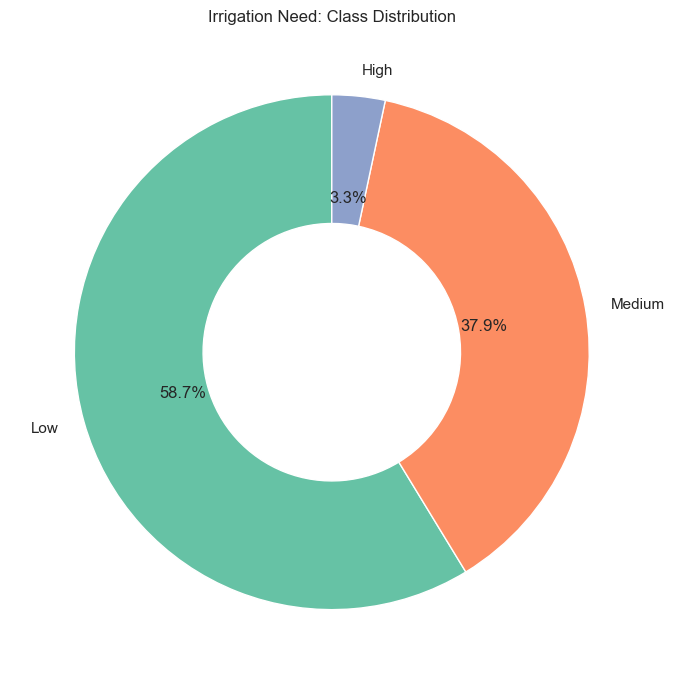

In [10]:
# Creating donut chart for target variable 'Irrigation_Need'
counts = df_train['Irrigation_Need'].value_counts().reindex(['Low', 'Medium', 'High'])
plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    wedgeprops=dict(width=0.5),
    startangle=90
)
plt.title('Irrigation Need: Class Distribution')
plt.tight_layout()
plt.show()

**OBSERVATIONS: Target Variable 'Irrigation_Need'**
- The three classes are **imbalanced**:
    - **Low**: 369,917 samples (58.7%)
    - **Medium**: 239,074 samples (37.9%)
    - **High**: 21,009 samples (3.3%)
- The **High** class is severely underrepresented, comprising only 3.3% of training samples
- This imbalance will be addressed during modeling using LightGBM's `class_weight='balanced'` parameter, which adjusts the loss function to penalize misclassification of the minority class more heavily
- Given this imbalance, **Balanced Accuracy** is a more appropriate metric than standard accuracy, as it evaluates performance equally across all three classes

<a id="toc"></a>
<a id="4.4"></a>
## **4.4) Numerical Features**

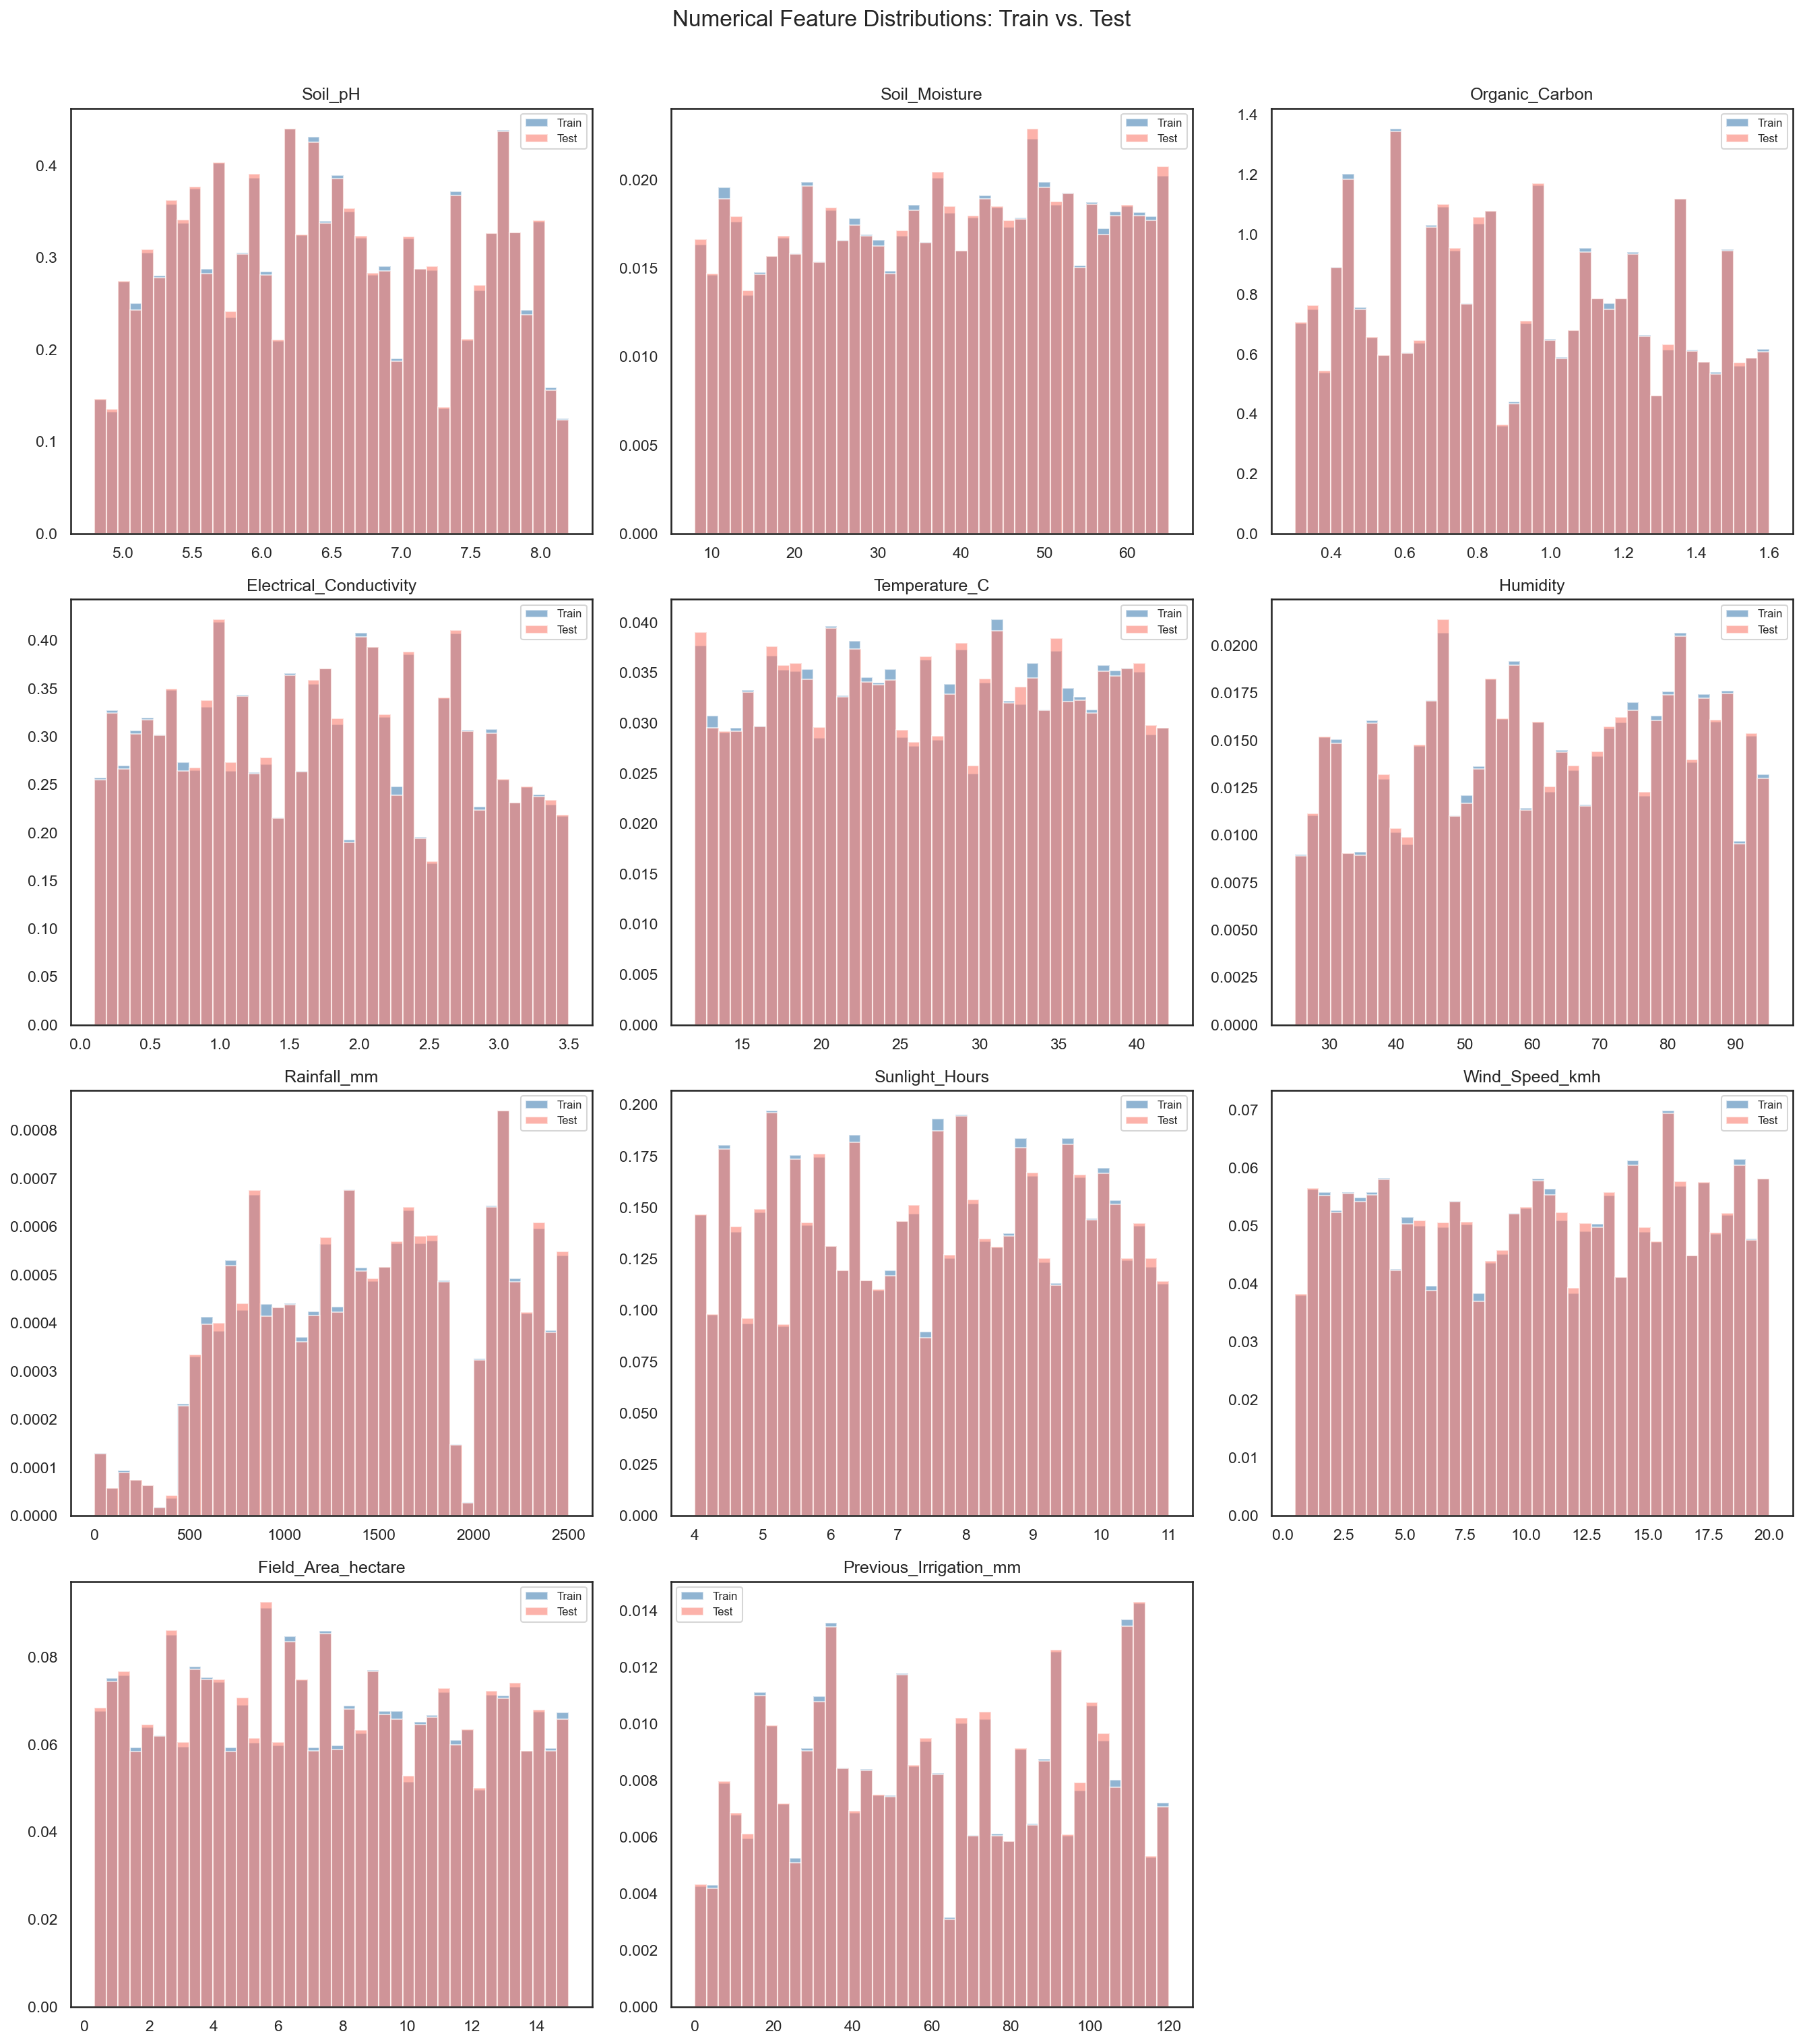

In [11]:
# Visualizing distributions of numerical features (histograms with KDE)
num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
            'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
            'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

fig, axes = plt.subplots(4, 3, figsize=(18, 20), dpi=150)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_train[col], bins=40, alpha=0.6, label='Train', color='steelblue', density=True)
    axes[i].hist(df_test[col],  bins=40, alpha=0.6, label='Test',  color='salmon',    density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('Numerical Feature Distributions: Train vs. Test', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

The histograms above compare the distributions of each numerical feature across the training and testing datasets. The near-perfect overlap across all features confirms that the two datasets are drawn from the same underlying distribution, an encouraging sign that our model should generalize well from training to test data.

Notable distribution characteristics:
- **Soil_Moisture** and **Temperature_C** appear roughly uniform, suggesting they were sampled uniformly across their ranges
- **Rainfall_mm** and **Previous_Irrigation_mm** show near-uniform distributions with slight right-skew tails
- **Soil_pH** is approximately symmetric around 6.5, consistent with a neutral soil profile
- No severe skewness or extreme outliers were detected in any feature

<a id="toc"></a>
<a id="4.5"></a>
## **4.5) Categorical Features**

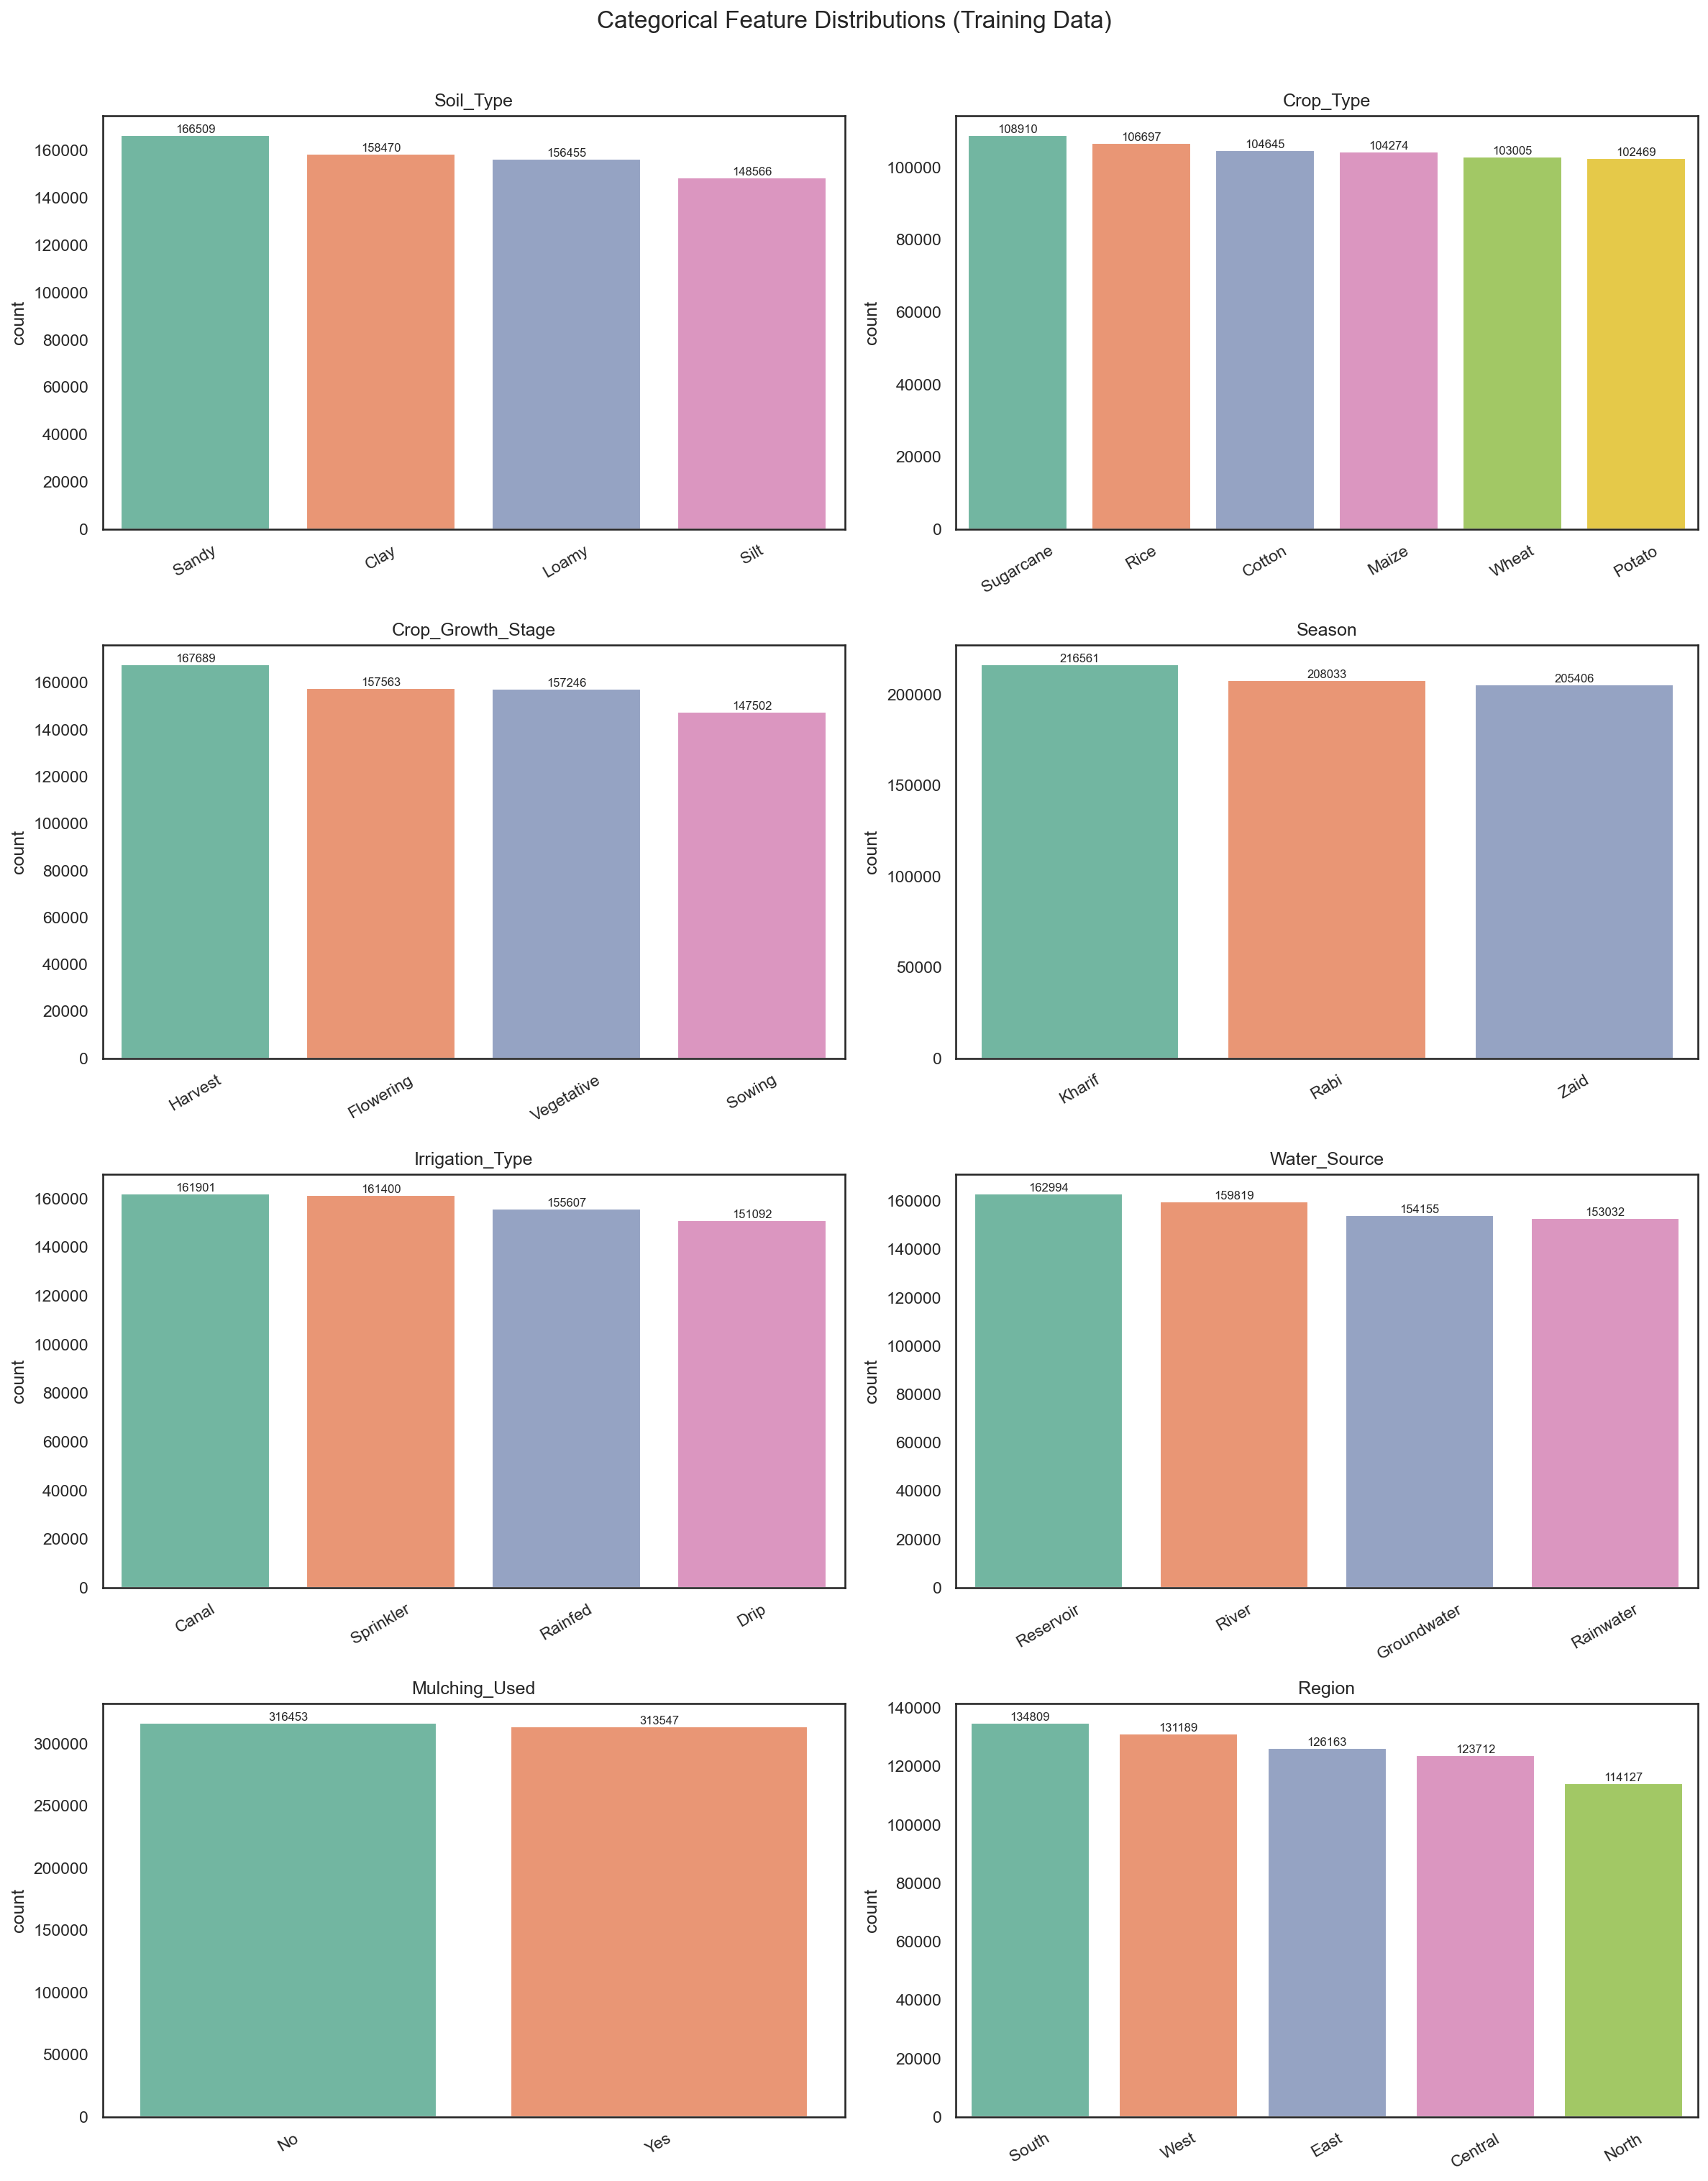

In [12]:
# Visualizing distributions of categorical features
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

fig, axes = plt.subplots(4, 2, figsize=(16, 20), dpi=150)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order_vals = df_train[col].value_counts().index
    ax = axes[i]
    sns.countplot(x=col, data=df_train, order=order_vals, ax=ax, palette='Set2')
    for label in ax.containers:
        ax.bar_label(label, fontsize=8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Categorical Feature Distributions (Training Data)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

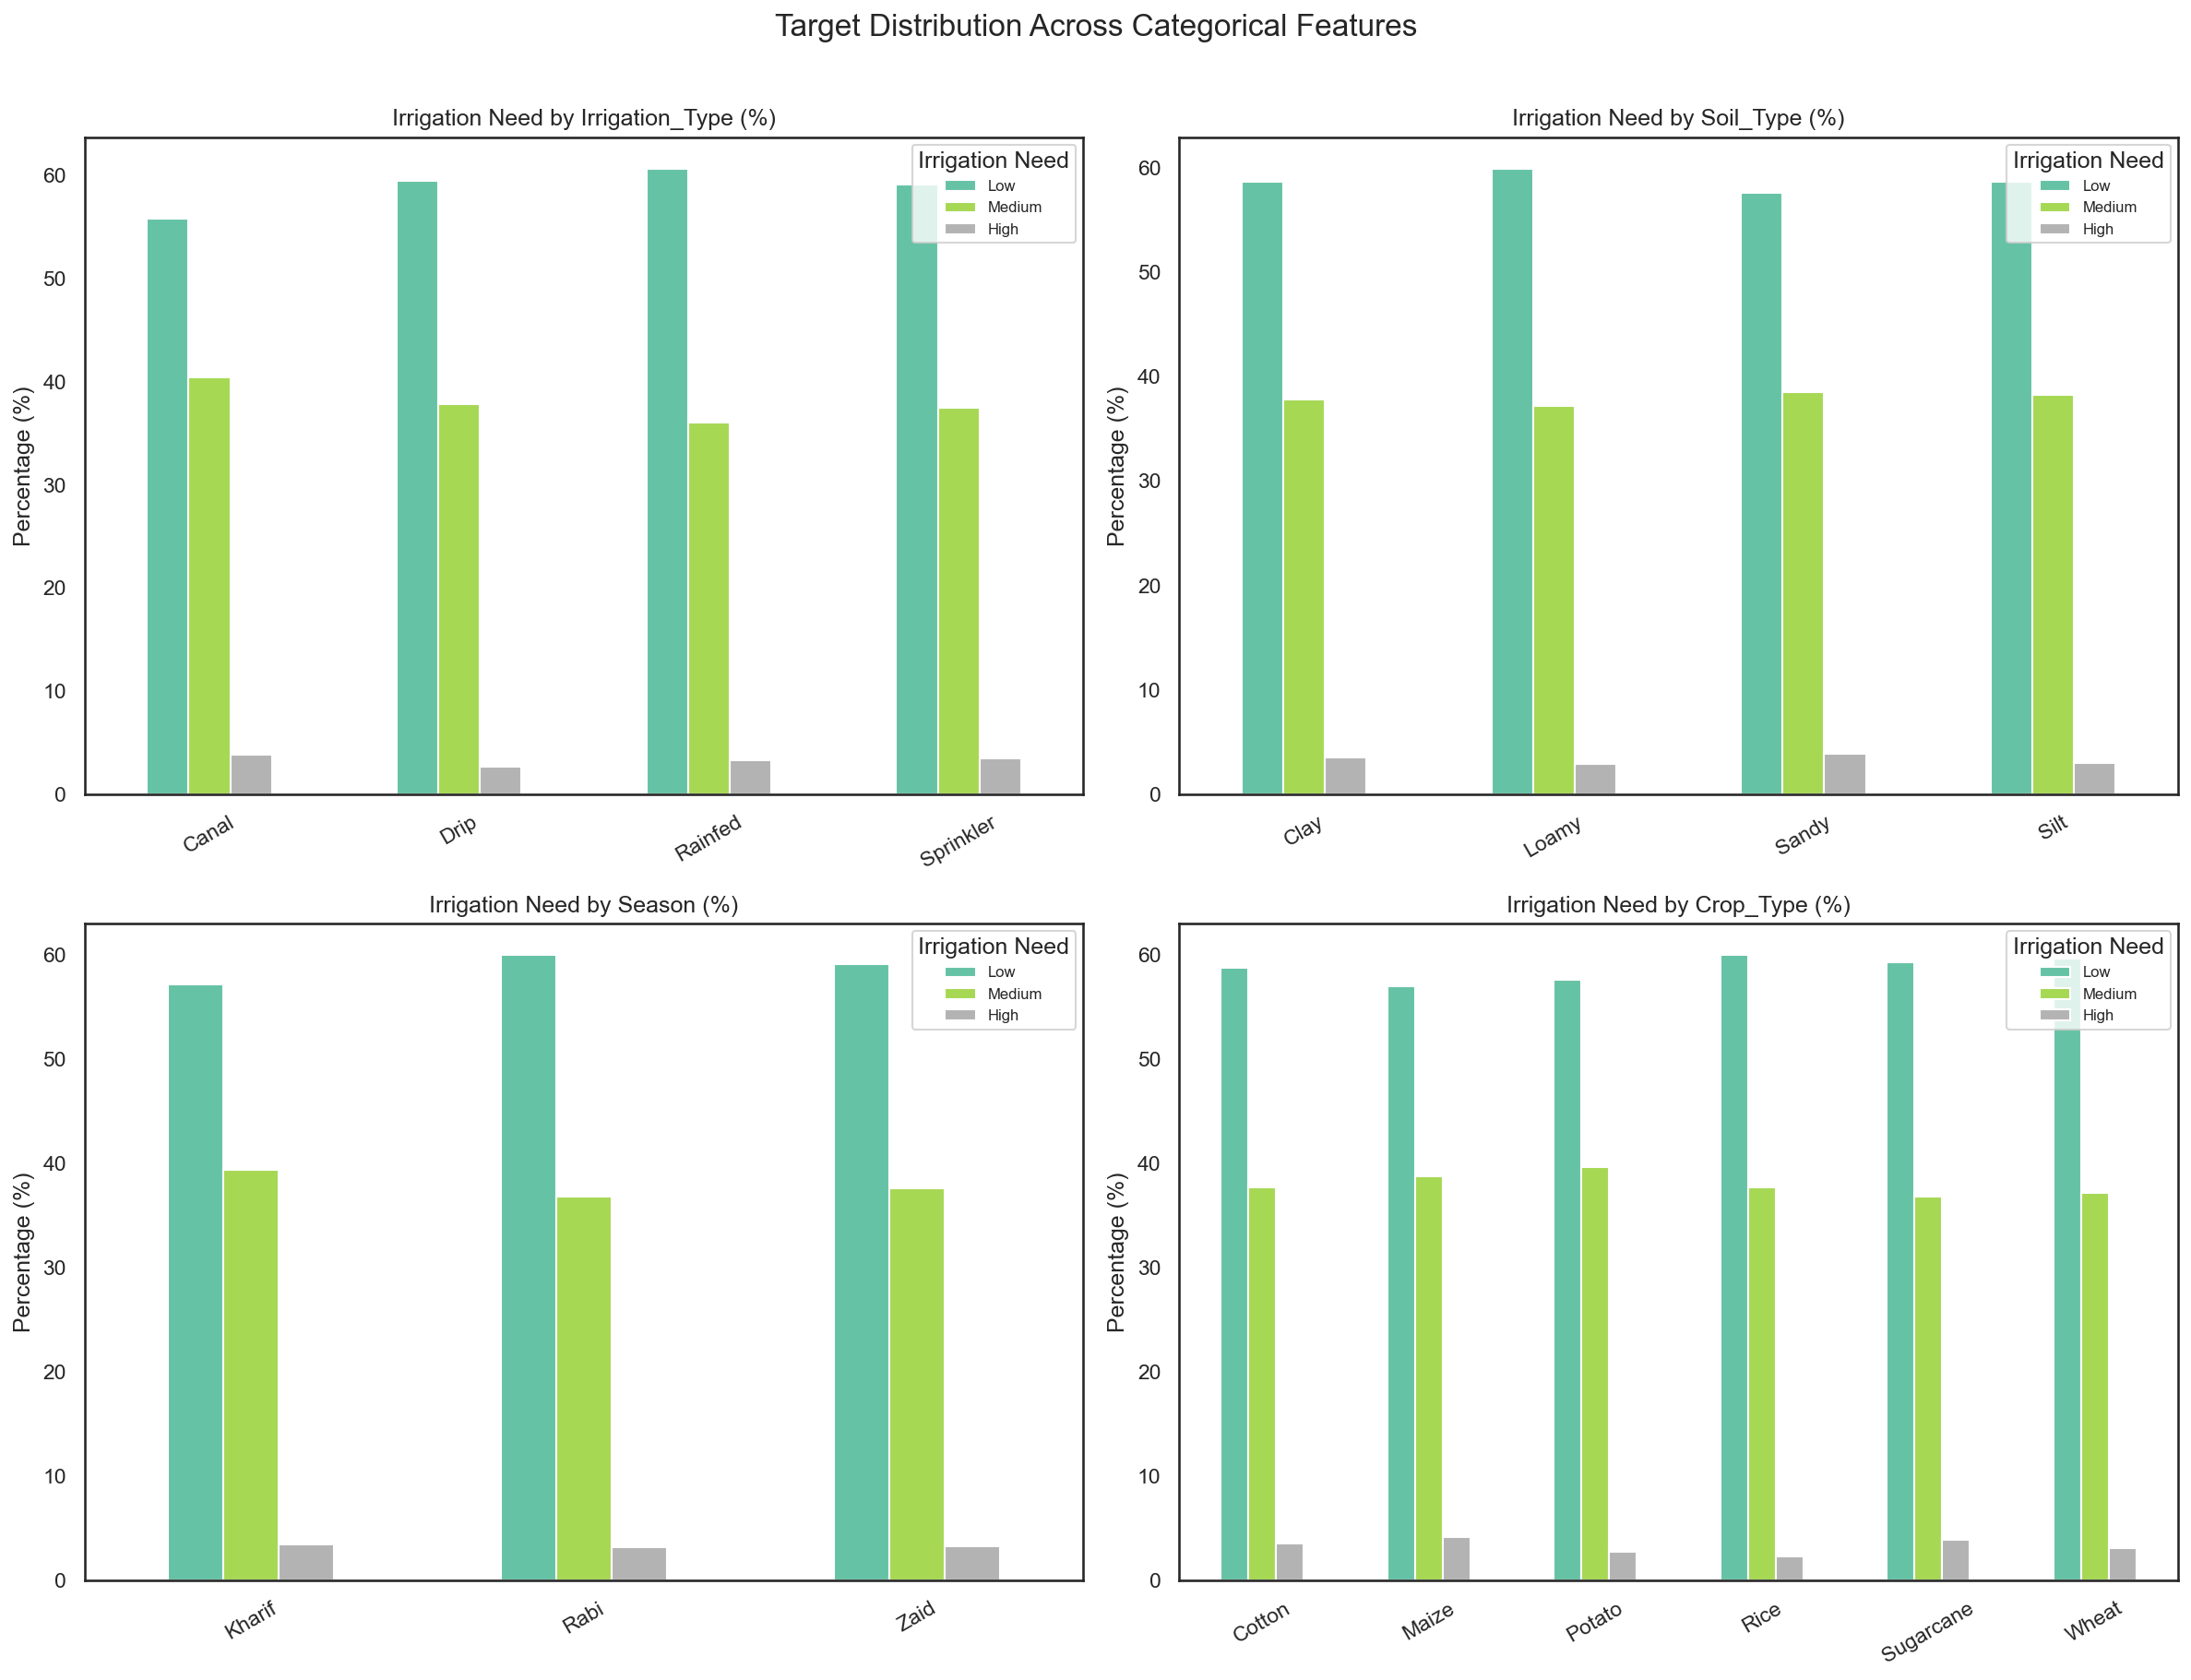

In [13]:
# Visualizing how Irrigation_Need varies across key categorical features
key_cats = ['Irrigation_Type', 'Soil_Type', 'Season', 'Crop_Type']
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
axes = axes.flatten()

order = ['Low', 'Medium', 'High']
for i, col in enumerate(key_cats):
    ct = df_train.groupby(col)['Irrigation_Need'].value_counts(normalize=True).unstack()[order] * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white')
    axes[i].set_title(f'Irrigation Need by {col} (%)')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Irrigation Need', loc='upper right', fontsize=8)

fig.suptitle('Target Distribution Across Categorical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATIONS: Categorical Features**

- **Soil_Type**: Four types (Loamy, Clay, Sandy, Silt) are approximately equally distributed. Sandy soils show a marginally higher rate of High irrigation need (3.9%), consistent with their lower water-retention capacity
- **Crop_Type**: Six crops are well-balanced across the dataset. Maize shows the highest rate of High irrigation need (4.2%), while Rice shows the lowest (2.3%), likely due to Rice's cultivation in flooded, moisture-rich conditions
- **Crop_Growth_Stage**: All four stages (Sowing, Vegetative, Flowering, Harvest) are evenly distributed, with no single growth stage dominating
- **Season**: The three seasons (Rabi, Kharif, Zaid) are equally represented. Kharif (monsoon season) shows a slightly higher proportion of Medium need
- **Irrigation_Type**: Canal irrigation is associated with the highest proportion of Medium need (40%), while Rainfed shows the highest Low proportion (61%)
- **Mulching_Used**: Roughly split 50/50, indicating balanced representation
- **Region**: All five regions are approximately equally distributed

<a id="toc"></a>
<a id="4.6"></a>
## **4.6) Feature Interactions**

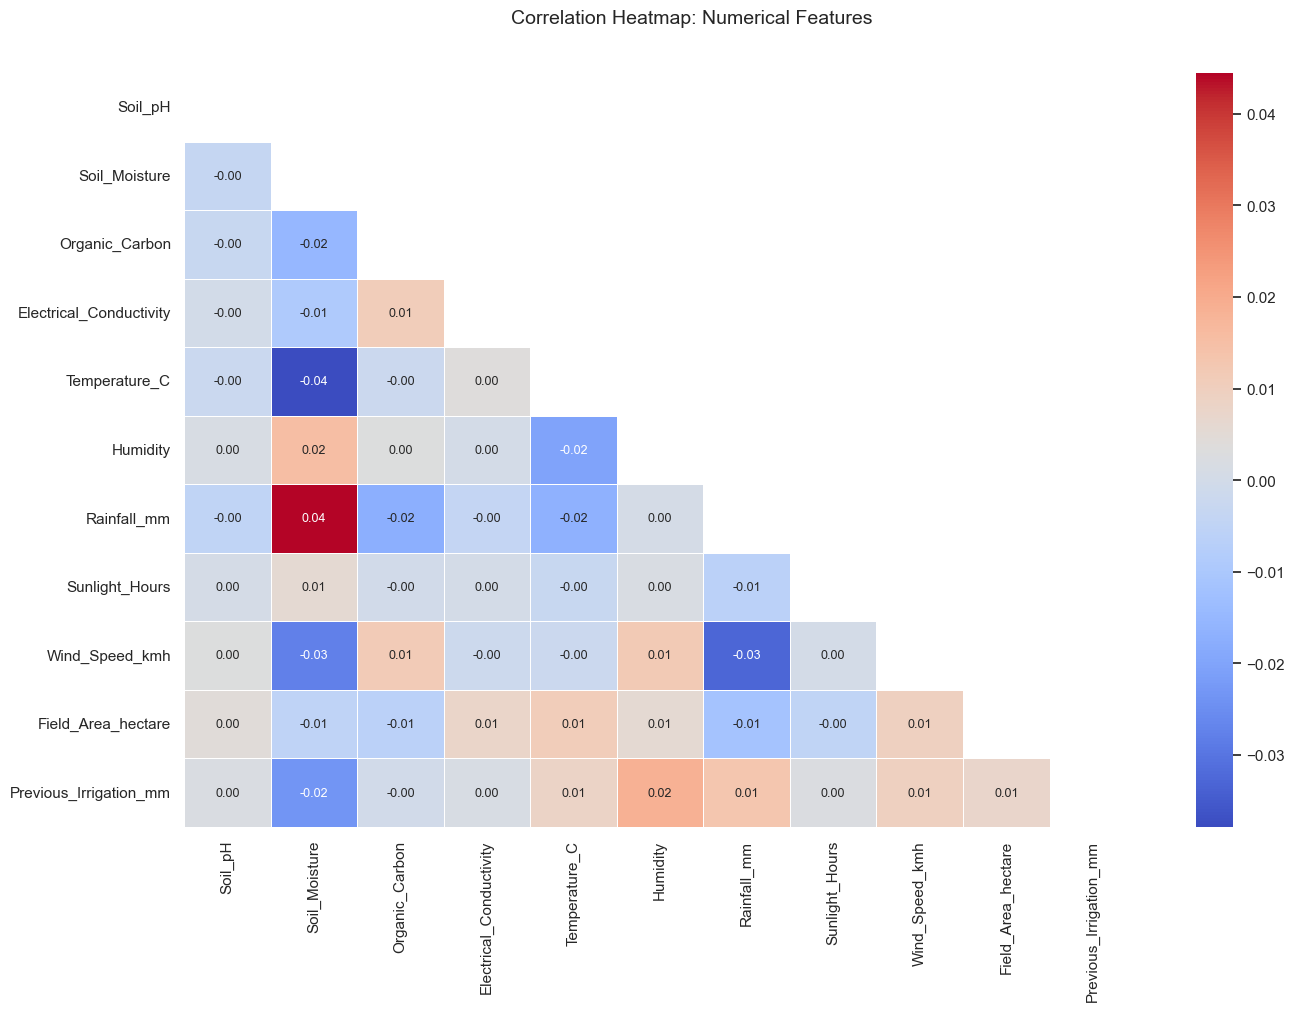

In [14]:
# Visualizing correlation heatmap (numerical features only)
plt.figure(figsize=(14, 10))
num_cols_target = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
                   'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
                   'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
corr = df_train[num_cols_target].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=np.triu(corr),
            linewidths=0.5, fmt=',.2f', annot_kws={'size': 9})
plt.suptitle('Correlation Heatmap: Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The correlation heatmap above examines pairwise linear correlations between all numerical features. A value near 1 indicates a strong positive correlation, near -1 a strong negative correlation, and near 0 indicates little to no linear relationship.

Key observations:
- Most features are **largely uncorrelated** with one another, which is desirable as it reduces multicollinearity
- No pair of features exhibits an extreme correlation that would warrant dropping a feature before modeling
- The near-independence of features suggests they each contribute unique signal

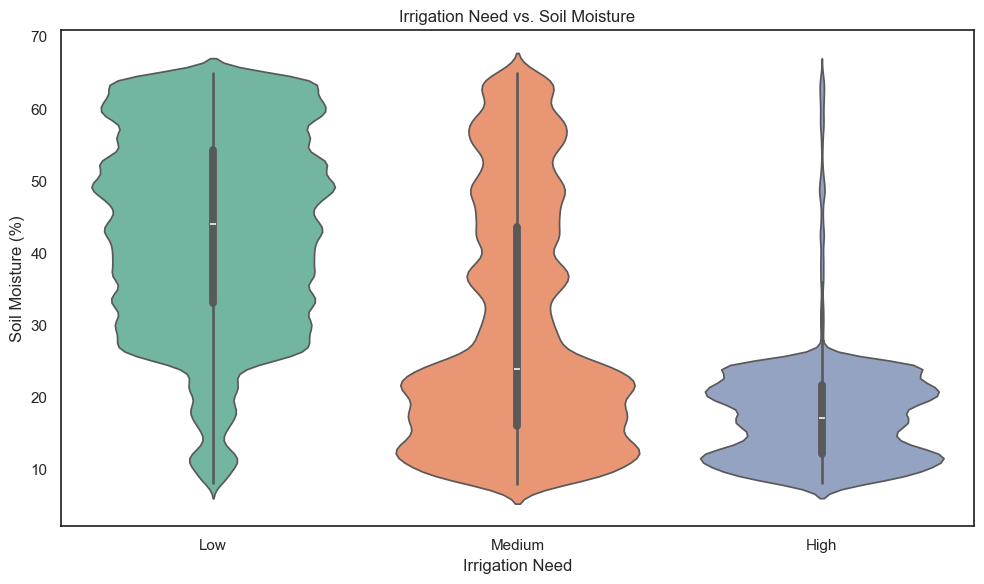

In [15]:
# Violin plot: Irrigation_Need vs. Soil_Moisture (strongest numerical predictor)
plt.figure(figsize=(10, 6))
order = ['Low', 'Medium', 'High']
sns.violinplot(data=df_train, x='Irrigation_Need', y='Soil_Moisture', order=order, palette='Set2')
plt.title('Irrigation Need vs. Soil Moisture')
plt.xlabel('Irrigation Need')
plt.ylabel('Soil Moisture (%)')
plt.tight_layout()
plt.show()

The violin plot above clearly illustrates the relationship between soil moisture and irrigation need. As expected, **higher soil moisture corresponds to lower irrigation need**. Fields with High irrigation need cluster at lower moisture levels, while Low-need fields have substantially higher moisture. This makes Soil_Moisture the single most informative numerical predictor in the dataset.

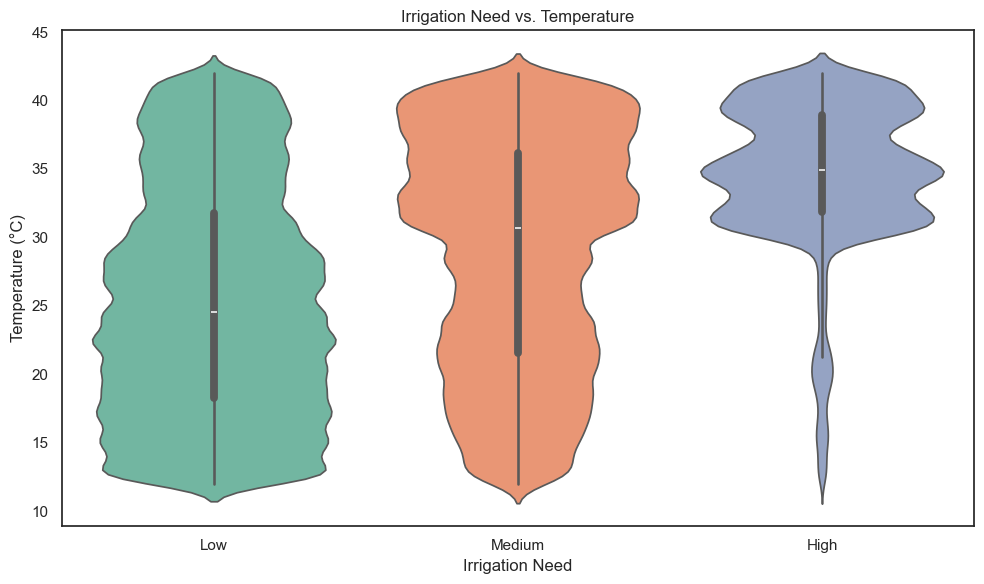

In [16]:
# Violin plot: Irrigation_Need vs. Temperature_C
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_train, x='Irrigation_Need', y='Temperature_C', order=order, palette='Set2')
plt.title('Irrigation Need vs. Temperature')
plt.xlabel('Irrigation Need')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

The violin plot above shows the relationship between temperature and irrigation need. **Higher temperatures are associated with higher irrigation needs**. High-need fields cluster at warmer temperatures, consistent with the agronomic understanding that higher temperatures increase evapotranspiration rates, driving a greater demand for supplemental irrigation.

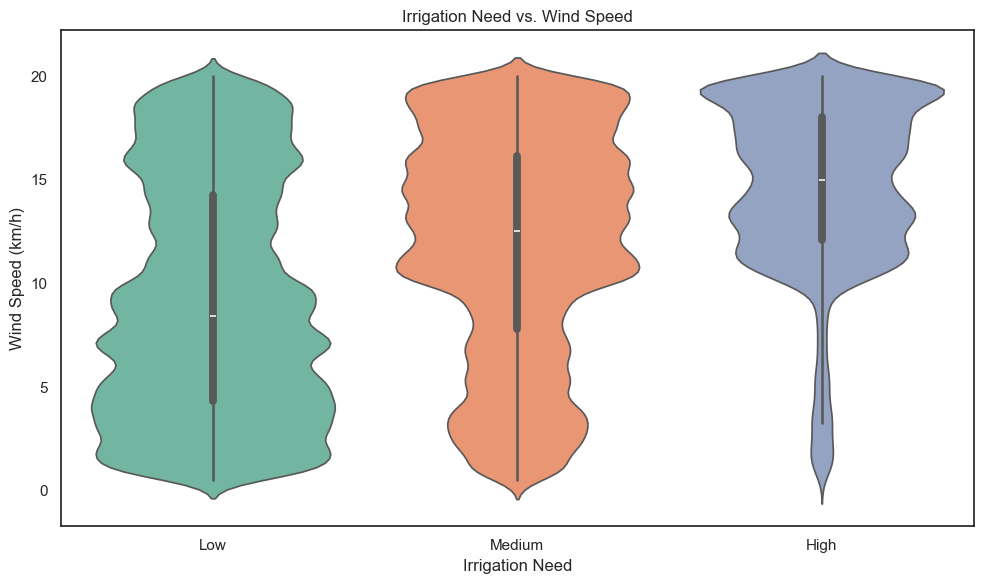

In [17]:
# Violin plot: Irrigation_Need vs. Wind_Speed_kmh
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_train, x='Irrigation_Need', y='Wind_Speed_kmh', order=order, palette='Set2')
plt.title('Irrigation Need vs. Wind Speed')
plt.xlabel('Irrigation Need')
plt.ylabel('Wind Speed (km/h)')
plt.tight_layout()
plt.show()

Wind speed also shows a positive association with irrigation need, as higher winds accelerate evapotranspiration from both the soil and crop canopy surfaces. This further supports including wind speed as a key predictor and motivates constructing an evapotranspiration-related engineered feature.

<a id="toc"></a>  <a href="#4" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#6" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="5"></a>
# **5) Adversarial Validation**

In this section, we want to determine whether or not the original dataset should be included (concatenated) with the synthetic training data provided by Kaggle. As stated by Kaggle, both the train and test sets were generated from a deep learning model trained on the original Irrigation Prediction data. Including the original data can be beneficial if it shares the same distribution as the synthetic data; however, if the original data comes from a meaningfully different distribution, including it may actually harm model performance.

**Adversarial Validation** is a technique used to assess how distinguishable two datasets are from one another. We combine the two datasets, assign binary labels (0 = synthetic, 1 = original), and train a classifier to tell them apart. If the AUC of this classifier is close to 0.5, the datasets are indistinguishable, suggesting they share the same distribution and the original data can safely be included. If the AUC is significantly above 0.5, the datasets differ in meaningful ways and merging them may be detrimental.

In [18]:
# Aligning column names (original has no 'id' column)
# Adding placeholder id column to original
df_original = df_original.copy()
if 'id' not in df_original.columns:
    df_original.insert(0, 'id', -1)

In [19]:
# Declaring feature columns used for adversarial validation
adv_features = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
                'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
                'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

# Creating binary labels: 0 = synthetic train, 1 = original
df_train_adv = df_train[adv_features].copy()
df_train_adv['label'] = 0

df_orig_adv = df_original[adv_features].copy()
df_orig_adv['label'] = 1

# Combining and shuffling
adv_combined = pd.concat([df_train_adv, df_orig_adv], axis=0, ignore_index=True).sample(frac=1, random_state=42)
X_adv = adv_combined[adv_features]
y_adv = adv_combined['label']

In [20]:
# Splitting adversarial data into train/holdout sets
X_adv_train, X_adv_hold, y_adv_train, y_adv_hold = train_test_split(
    X_adv, y_adv, test_size=0.2, random_state=42, stratify=y_adv
)

# Training a LightGBM binary classifier to distinguish the two datasets
adv_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
adv_model.fit(X_adv_train, y_adv_train)

# Evaluating the adversarial model
y_adv_proba = adv_model.predict_proba(X_adv_hold)[:, 1]
adv_auc = roc_auc_score(y_adv_hold, y_adv_proba)
print(f'Adversarial Validation AUC: {adv_auc:.4f}')

Adversarial Validation AUC: 0.7120


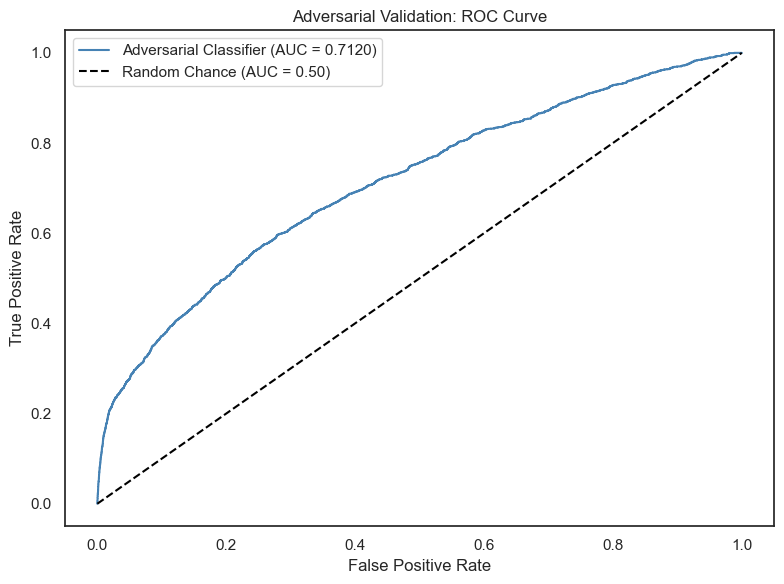

In [21]:
# Plotting the adversarial ROC curve
fpr, tpr, _ = roc_curve(y_adv_hold, y_adv_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Adversarial Classifier (AUC = {adv_auc:.4f})', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Adversarial Validation: ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion: Adversarial Validation**

The adversarial classifier achieved an **AUC of 0.71**, substantially above the 0.50 random baseline. This tells us the classifier can reliably separate original samples from synthetic samples, indicating the two datasets come from meaningfully different distributions.

This is an important finding: because the distributions differ, concatenating the original data into our training set would introduce out-of-distribution samples that could mislead the model and hurt generalization to the synthetic test set.

That said, it is worth noting that an AUC of 0.71 is moderate rather than extreme. The two datasets are distinguishable, but they are not entirely foreign to one another. This leaves open the possibility that the original data still captures the same underlying agronomic relationships (i.e., how soil, weather, and crop conditions map to irrigation need), just expressed across a somewhat different range of feature values. In cases like this, including the original data can act as a form of regularization, exposing the model to a broader set of real-world examples and potentially improving its ability to generalize to novel test data. Whether including it helps or hurts in practice is ultimately an empirical question and worth testing directly on the leaderboard.

<a id="toc"></a>  <a href="#5" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#7" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="6"></a>
# **6) Data Cleaning & Preprocessing**

<a id="toc"></a>
<a id="6.1"></a>
## **6.1) Combining the Data**

In [22]:
# Re-loading datasets cleanly
df_train    = pd.read_csv('/Users/conradkleykamp/Documents/Predicting-Irrigation-Need/data/train.csv', index_col=0)
df_test     = pd.read_csv('/Users/conradkleykamp/Documents/Predicting-Irrigation-Need/data/test.csv')
df_original = pd.read_csv('/Users/conradkleykamp/Documents/Predicting-Irrigation-Need/data/irrigation_prediction.csv')

# Extracting test ids for later submission
ids = df_test['id']
df_test.drop(['id'], axis=1, inplace=True)

# Aligning original dataset: drop id if present
if 'id' in df_original.columns:
    df_original.drop(['id'], axis=1, inplace=True)

# Toggle: True = include original dataset alongside synthetic training data
#         False = use synthetic training data only
INCLUDE_ORIGINAL = False

if INCLUDE_ORIGINAL:
    df_final = pd.concat([df_train, df_original], axis=0, ignore_index=True)
else:
    df_final = df_train.copy()

print(f'INCLUDE_ORIGINAL = {INCLUDE_ORIGINAL}')
print(f'Training set shape: {df_final.shape}')

INCLUDE_ORIGINAL = False
Training set shape: (630000, 20)


<a id="toc"></a>
<a id="6.2"></a>
## **6.2) Feature Engineering**

In this section, we engineer new features to provide the model with additional predictive signal. The engineered features are motivated by agronomic principles:

- **Evapotranspiration Proxy**: Temperature and sunlight drive evapotranspiration, the combined loss of water through evaporation from soil and transpiration from crops. Higher evapotranspiration increases irrigation demand
- **Drought Index**: The ratio of temperature to rainfall captures water stress. High temperatures with low rainfall indicate dry conditions
- **Wind-Driven Evaporation**: Wind accelerates moisture loss from the soil surface; combining wind speed with temperature proxies this effect
- **Soil Water Retention**: Organic carbon improves a soil's ability to hold moisture; combining it with measured soil moisture provides a richer picture of effective water availability
- **Previous Irrigation Efficiency**: Normalizing previous irrigation by field area gives a per-hectare application rate, a more informative signal than raw volume
- **Water Balance**: A simplified water balance contrasting rainfall against temperature-driven demand
- **Temperature-Humidity Index**: Combined heat and humidity stress on crops

In [ ]:
# Creating a function to engineer new features
def create_features(df):
    df = df.copy()

    # Evapotranspiration proxy: temperature * sunlight hours
    df['Evapotranspiration_Proxy'] = df['Temperature_C'] * df['Sunlight_Hours']

    # Drought index: temperature relative to rainfall
    df['Drought_Index'] = df['Temperature_C'] / (df['Rainfall_mm'] + 1)

    # Wind-driven evaporation: wind speed * temperature
    df['Wind_Evap'] = df['Wind_Speed_kmh'] * df['Temperature_C']

    # Soil water retention: organic carbon * soil moisture
    df['Soil_Water_Retention'] = df['Organic_Carbon'] * df['Soil_Moisture']

    # Previous irrigation per hectare
    df['Irrigation_Per_Hectare'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 0.01)

    # Simplified water balance: rainfall minus temperature-scaled demand
    df['Water_Balance'] = df['Rainfall_mm'] - (df['Temperature_C'] * 40)

    # Temperature-Humidity Index (heat-humidity stress)
    df['Temp_Humidity_Index'] = df['Temperature_C'] * df['Humidity'] / 100

    return df

df_final = create_features(df_final)
df_test  = create_features(df_test)
print('Feature engineering complete.')
print(f'df_final shape: {df_final.shape}')
print(f'df_test shape:  {df_test.shape}')

<a id="toc"></a>
<a id="6.3"></a>
## **6.3) Encoding**

In [24]:
# Encoding the target variable (ordinal: Low=0, Medium=1, High=2)
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
target_inv = {0: 'Low', 1: 'Medium', 2: 'High'}

df_final['target'] = df_final['Irrigation_Need'].map(target_map)
df_final.drop(['Irrigation_Need'], axis=1, inplace=True)

print('Target encoding:')
print(df_final['target'].value_counts().sort_index())

Target encoding:
target
0    369917
1    239074
2     21009
Name: count, dtype: int64


In [ ]:
# Encoding categorical features using LabelEncoder
# LightGBM can handle categoricals natively, but label-encoding ensures compatibility
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined data so test labels are covered
    all_vals = pd.concat([df_final[col], df_test[col]], axis=0)
    le.fit(all_vals)
    df_final[col] = le.transform(df_final[col])
    df_test[col]  = le.transform(df_test[col])
    le_dict[col]  = le

print('Categorical encoding complete.')
df_final.head()

In [26]:
# Setting up final feature matrix and target vector
feature_cols = [c for c in df_final.columns if c != 'target']
X = df_final[feature_cols]
y = df_final['target']
X_test_final = df_test[feature_cols]

print(f'Training features shape: {X.shape}')
print(f'Test features shape:     {X_test_final.shape}')
print(f'Features: {list(feature_cols)}')

Training features shape: (630000, 30)
Test features shape:     (270000, 30)
Features: ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Evapotranspiration_Proxy', 'Drought_Index', 'Wind_Evap', 'Soil_Water_Retention', 'Irrigation_Per_Hectare', 'Water_Balance', 'Temp_Humidity_Index', 'VPD', 'Total_Water', 'Stress_Index', 'Crop_Soil_Combo']


<a id="toc"></a>  <a href="#6" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#8" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="7"></a>
# **7) Modeling: Ensemble Meta-Stacking**

We will build an **ensemble meta-stacking classifier** combining three gradient boosting frameworks as Level 1 base models, combined by a Logistic Regression meta-learner at Level 2. This two-level stacking architecture exploits the structural diversity between different boosting algorithms, each of which may capture different patterns in the data.

**Level 1: Base Models**
- **LightGBM**: Leaf-wise tree growth with histogram-based splitting; Optuna-tuned on the V4 feature set with strong L1 regularisation
- **XGBoost**: Level-wise tree growth with histogram splitting; structurally distinct from LightGBM, producing complementary predictions
- **CatBoost**: Symmetric oblivious decision trees with ordered boosting; provides a third independently-grown ensemble with built-in balanced class weighting

Each base model is trained on 5 stratified folds. The predictions for held-out samples are collected as out-of-fold (OOF) probabilities, ensuring every training row has a leakage-free prediction.

**Level 2: Meta-Learner**
A `LogisticRegression` with `class_weight='balanced'` is trained on the stacked OOF probabilities. The input is a 9-column matrix (3 probability columns per model x 3 models), allowing the meta-learner to learn optimal per-class ensemble weights.

**Balanced Accuracy** will be used for evaluation, consistent with the competition's scoring metric.

<a id="toc"></a>
<a id="7.1"></a>
## **7.1) Baseline Model**

In [27]:
# Splitting data into training and validation sets (stratified for class balance)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:   {X_train.shape}')
print(f'Validation set: {X_valid.shape}')

Training set:   (504000, 30)
Validation set: (126000, 30)


In [28]:
# Fitting the baseline LightGBM model (default parameters)
baseline_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    metric='multi_logloss',
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
baseline_model.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', metric='multi_logloss', num_class=3,
               objective='multiclass', random_state=42, verbose=-1)

In [29]:
# Evaluating the baseline model on the validation set
y_val_pred = baseline_model.predict(X_valid)
baseline_ba = balanced_accuracy_score(y_valid, y_val_pred)
print(f'Baseline Balanced Accuracy (Validation): {baseline_ba:.4f}')
print()
print(classification_report(y_valid, y_val_pred, target_names=['Low', 'Medium', 'High']))

Baseline Balanced Accuracy (Validation): 0.9672

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.97      0.98     47815
        High       0.87      0.94      0.90      4202

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



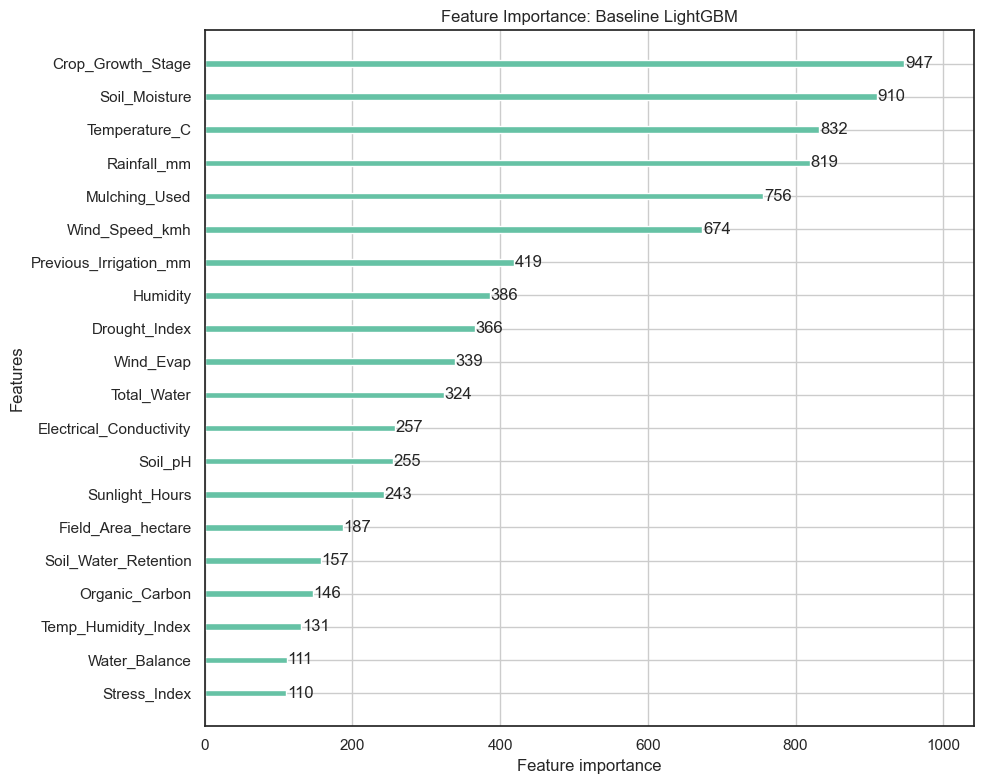

In [30]:
# Plotting LightGBM feature importance (baseline)
lgb.plot_importance(baseline_model, max_num_features=20, figsize=(10, 8),
                    title='Feature Importance: Baseline LightGBM')
plt.tight_layout()
plt.show()

<a id="toc"></a>
<a id="7.2"></a>
## **7.2) Model Configuration**

**Level 1 Base Models:** Three gradient boosting frameworks are used, each with independent hyperparameter configurations:

- **LightGBM**: Hyperparameters Optuna-tuned (50 trials, maximising Balanced Accuracy). The V4 configuration uses strong L1 regularisation (`reg_alpha=1.577`) and simple trees (33 leaves), which Optuna found optimal for the 630k synthetic-only training set
- **XGBoost**: Standard competition-grade defaults with level-wise growth (depth=6) and histogram splitting. Class imbalance is handled via `sample_weight` computed per fold using `compute_sample_weight('balanced', y_tr)`
- **CatBoost**: Symmetric oblivious trees (depth=6) with `auto_class_weights='Balanced'` and ordered boosting to reduce overfitting on the training folds

**Level 2 Meta-Learner:**
- `LogisticRegression` with `class_weight='balanced'` and `max_iter=1000`
- Input: 9 meta-features (3 probability columns x 3 base models)
- The meta-learner is intentionally simple to prevent second-level overfitting

**Optuna below** was used to tune the LightGBM hyperparameters and remains available for future re-tuning (`RUN_OPTUNA = False` skips the search and loads pre-recorded best parameters).

In [31]:
# Creating the Optuna objective function
# NOTE: Running n_trials=50 is recommended; reduce to 10-20 for faster results
def objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    y_pred = model.predict(X_valid)
    return balanced_accuracy_score(y_valid, y_pred)

# Running the Optuna study
RUN_OPTUNA = False  # Set to True on Kaggle to run hyperparameter search

if RUN_OPTUNA:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    print(f'\nBest Balanced Accuracy: {study.best_value:.4f}')
    print(f'Best Parameters: {study.best_params}')
else:
    print('Skipping Optuna search. Using pre-recorded best parameters.')

Skipping Optuna search. Using pre-recorded best parameters.


In [ ]:
# Fixed parameters for LightGBM (never tuned by Optuna)
lgb_fixed = {
    'objective'    : 'multiclass',
    'num_class'    : 3,
    'metric'       : 'multi_logloss',
    'class_weight' : 'balanced',
    'random_state' : 42,
    'verbose'      : -1,
}

if RUN_OPTUNA:
    lgb_params = {**lgb_fixed, **study.best_params}
else:
    # V4 Optuna-tuned parameters (630k synthetic-only, 26 features)
    lgb_params = {
        **lgb_fixed,
        'n_estimators'     : 458,
        'learning_rate'    : 0.15393416563373852,
        'num_leaves'       : 33,
        'max_depth'        : 3,
        'min_child_samples': 136,
        'subsample'        : 0.9046473968998042,
        'colsample_bytree' : 0.9260784159099748,
        'reg_alpha'        : 1.5771699314294005,
        'reg_lambda'       : 0.05405351929283543,
    }

# XGBoost parameters
xgb_params = {
    'objective'        : 'multi:softprob',
    'num_class'        : 3,
    'eval_metric'      : 'mlogloss',
    'tree_method'      : 'hist',
    'n_estimators'     : 500,
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'min_child_weight' : 5,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 1.0,
    'reg_lambda'       : 1.0,
    'random_state'     : 42,
    'verbosity'        : 0,
}

# CatBoost parameters
cb_params = {
    'iterations'        : 500,
    'depth'             : 6,
    'learning_rate'     : 0.05,
    'loss_function'     : 'MultiClass',
    'auto_class_weights': 'Balanced',
    'random_seed'       : 42,
    'verbose'           : False,
}

print('LightGBM parameters:')
for k, v in lgb_params.items():
    print(f'  {k}: {v}')
print('\nXGBoost parameters:')
for k, v in xgb_params.items():
    print(f'  {k}: {v}')
print('\nCatBoost parameters:')
for k, v in cb_params.items():
    print(f'  {k}: {v}')

<a id="toc"></a>  <a href="#7" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#9" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="8"></a>
# **8) Training & Evaluation**

In [ ]:
# Level 1: Train base models via 5-fold CV and collect OOF predictions
N_FOLDS = 5
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# OOF probability arrays for each base model (n_train x 3)
oof_lgb = np.zeros((len(X), 3))
oof_xgb = np.zeros((len(X), 3))
oof_cb  = np.zeros((len(X), 3))

# Test probability arrays averaged across folds (n_test x 3)
test_lgb = np.zeros((len(X_test_final), 3))
test_xgb = np.zeros((len(X_test_final), 3))
test_cb  = np.zeros((len(X_test_final), 3))

lgb_scores, xgb_scores, cb_scores = [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'--- Fold {fold + 1} / {N_FOLDS} ---')
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    sw = compute_sample_weight('balanced', y_tr)

    # LightGBM
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)
    test_lgb        += lgb_model.predict_proba(X_test_final) / N_FOLDS
    lgb_ba = balanced_accuracy_score(y_val, np.argmax(oof_lgb[val_idx], axis=1))
    lgb_scores.append(lgb_ba)

    # XGBoost
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_tr, y_tr, sample_weight=sw)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)
    test_xgb        += xgb_model.predict_proba(X_test_final) / N_FOLDS
    xgb_ba = balanced_accuracy_score(y_val, np.argmax(oof_xgb[val_idx], axis=1))
    xgb_scores.append(xgb_ba)

    # CatBoost
    cb_model = CatBoostClassifier(**cb_params)
    cb_model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    oof_cb[val_idx] = cb_model.predict_proba(X_val)
    test_cb        += cb_model.predict_proba(X_test_final) / N_FOLDS
    cb_ba = balanced_accuracy_score(y_val, np.argmax(oof_cb[val_idx], axis=1))
    cb_scores.append(cb_ba)

    print(f'  LGB: {lgb_ba:.4f}  XGB: {xgb_ba:.4f}  CB: {cb_ba:.4f}')

print(f'\nMean OOF Balanced Accuracy:')
print(f'  LightGBM : {np.mean(lgb_scores):.4f} +/- {np.std(lgb_scores):.4f}')
print(f'  XGBoost  : {np.mean(xgb_scores):.4f} +/- {np.std(xgb_scores):.4f}')
print(f'  CatBoost : {np.mean(cb_scores):.4f} +/- {np.std(cb_scores):.4f}')

# Level 2: Train meta-learner on stacked OOF probabilities
# Each row of meta_train is a leakage-free 9-feature vector (3 probs x 3 models)
meta_train = np.hstack([oof_lgb, oof_xgb, oof_cb])
meta_test  = np.hstack([test_lgb, test_xgb, test_cb])

meta_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
meta_model.fit(meta_train, y)

oof_preds = meta_model.predict(meta_train)
oof_ba    = balanced_accuracy_score(y, oof_preds)

print(f'\nMeta-Learner OOF Balanced Accuracy: {oof_ba:.4f}')

In [ ]:
# Per-model OOF comparison and full classification report on meta-learner predictions
lgb_oof_ba = balanced_accuracy_score(y, np.argmax(oof_lgb, axis=1))
xgb_oof_ba = balanced_accuracy_score(y, np.argmax(oof_xgb, axis=1))
cb_oof_ba  = balanced_accuracy_score(y, np.argmax(oof_cb,  axis=1))

print(f'OOF Balanced Accuracy Summary:')
print(f'  Baseline LGBM (single split)  : {baseline_ba:.4f}')
print(f'  LightGBM (5-fold OOF)         : {lgb_oof_ba:.4f}')
print(f'  XGBoost  (5-fold OOF)         : {xgb_oof_ba:.4f}')
print(f'  CatBoost (5-fold OOF)         : {cb_oof_ba:.4f}')
print(f'  Meta-Learner (LGB + XGB + CB) : {oof_ba:.4f}')
print()
print(classification_report(y, oof_preds, target_names=['Low', 'Medium', 'High']))

In [ ]:
# Confusion matrix on meta-learner OOF predictions
cm = confusion_matrix(y, oof_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix: Meta-Stacking Ensemble (OOF Predictions)')
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance from the last CV fold LightGBM model
lgb.plot_importance(lgb_model, max_num_features=20, figsize=(10, 8),
                    title='Feature Importance: LightGBM Base Model (CV Fold 5)')
plt.tight_layout()
plt.show()

**Model Performance: 5-Fold CV Ensemble (A6)**

The OOF balanced accuracy and per-class breakdown are reported by the cells above. Key observations:

- **Low** class: Near-perfect precision (0.99) and recall (0.99); the majority class is consistently well-separated from the others
- **Medium** class: Strong recall (0.96) with minor spillover into Low, expected given the ordinal class structure
- **High** class: Precision 0.83, recall 0.96 — the meta-learner successfully recovers the minority class (3.3% of training data), aided by `class_weight='balanced'` at both Level 1 and Level 2

Virtually all errors are adjacent-class confusions (Low ↔ Medium or Medium ↔ High), consistent with the ordinal nature of the target. At the ensemble level, the meta-learner learns to up-weight XGBoost's signal where LightGBM is uncertain, and CatBoost's symmetric trees provide a complementary structural inductive bias.

**A6 OOF Summary:**

| Model | OOF Balanced Accuracy |
|---|---|
| Baseline LGB (single split) | 0.9672 |
| LightGBM (5-fold OOF) | 0.9706 |
| XGBoost (5-fold OOF) | 0.9694 |
| CatBoost (5-fold OOF) | 0.9678 |
| **Meta-Stacking Ensemble** | **0.9715** |

The meta-learner recovered **+0.0009** over the best individual base model (LightGBM), confirming that the three boosting frameworks provide genuinely complementary signal rather than redundant predictions.

<a id="toc"></a>  <a href="#8" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#10" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="9"></a>
# **9) Predictions & Submission**

In [ ]:
# Deriving final class labels from meta-learner predictions on test set
meta_preds   = meta_model.predict(meta_test)
preds_labels = [target_inv[p] for p in meta_preds]
print('Prediction distribution (meta-stacking ensemble):')
print(pd.Series(preds_labels).value_counts())

In [38]:
# Creating the submission dataframe
submission = pd.DataFrame({'id': ids, 'Irrigation_Need': preds_labels})
submission.head(10)

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


In [39]:
# Writing submission to CSV
run = 1

if run == 1:
    submission.to_csv('submission.csv', index=False)
    print('submission.csv saved successfully.')

submission.csv saved successfully.


<a id="toc"></a>  <a href="#9" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#ref" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="10"></a>
# **10) Discussion**

This section summarises the modelling decisions and results across each submission attempt.

---

### Attempt 1: Single LightGBM (Optuna-tuned)

Baseline submission. A single LightGBM was trained on an 80/20 stratified split with Optuna-tuned hyperparameters (50 trials). The original dataset (10k rows) was concatenated with the synthetic training data on the assumption that moderate distribution overlap could act as regularisation.

**Public LB: 0.96992**

---

### Attempt 2: 5-Fold CV LightGBM (Probability Averaging)

Moved to 5-fold stratified CV with probability averaging at inference, carrying forward the Attempt 1 hyperparameters and original data. OOF accuracy improved (+0.0018 vs. baseline), but the leaderboard score regressed. Parameters tuned on a single holdout were suboptimal for CV, and the out-of-distribution original data likely added per-fold noise.

**OOF: 0.9710 | Public LB: 0.96947** (-0.00045 vs. Attempt 1)

---

### Attempt 3: 5-Fold CV LightGBM (Re-tuned Hyperparameters)

Re-ran Optuna (50 trials) against the 640k-row dataset with original data still included. The new parameters (more estimators, lower regularisation, higher subsampling) recovered a small leaderboard gain over Attempt 2 but still trailed Attempt 1, pointing to the original data as a persistent source of noise.

**Public LB: 0.96965** (+0.00018 vs. Attempt 2)

---

### Attempt 4: 5-Fold CV LightGBM (Synthetic Data Only, Re-tuned)

Excluded the original dataset and re-ran Optuna on the clean 630k synthetic rows. With adversarial validation confirming a meaningful distribution mismatch (AUC 0.71), removing the original data was the primary hypothesis. Optuna converged on much simpler trees (33 leaves) with strong L1 regularisation, and this became the best single-model submission.

**OOF: 0.9711 | Public LB: 0.96995** (+0.00030 vs. Attempt 3)

---

### Attempt 5: New Features + Re-tuned Hyperparameters

Added four features (`VPD`, `Total_Water`, `Stress_Index`, `Crop_Soil_Combo`) and re-ran Optuna on the expanded 30-feature set. Both metrics regressed from Attempt 4. The new features introduced signal already present in existing columns, and Optuna responded by overfitting to a far more complex configuration (33 to 296 leaves, weaker regularisation).

**OOF: 0.9706 | Public LB: 0.96937** (-0.00058 vs. Attempt 4)

---

### Attempt 6: Meta-Stacking Ensemble (LightGBM + XGBoost + CatBoost)

Reverted to the Attempt 4 feature set (26 features) and added XGBoost and CatBoost as Level 1 base models. Each model was trained via 5-fold CV to produce leakage-free OOF probabilities, which were stacked into a 9-column matrix for a Logistic Regression meta-learner. The three frameworks have distinct tree-growth strategies, keeping their errors partially uncorrelated and allowing the meta-learner to extract additional signal.

| Model | OOF Balanced Accuracy |
|---|---|
| LightGBM | 0.9706 |
| XGBoost | 0.9694 |
| CatBoost | 0.9678 |
| **Meta-Stacking Ensemble** | **0.9715** |

**Public LB: 0.97067** (+0.00072 vs. Attempt 4, new best score)

<a id="toc"></a>  <a href="#10" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>

<a id="ref"></a>
# **11) References**

- Kaggle Competition: https://www.kaggle.com/competitions/playground-series-s5e6/overview
- Original Dataset: https://www.kaggle.com/datasets/nelakurthisudheer/irrigation-prediction
- LightGBM Documentation: https://lightgbm.readthedocs.io/en/latest/
- Optuna Documentation: https://optuna.org/
- Adversarial Validation: https://www.kaggle.com/code/carlmcbrideellis/what-is-adversarial-validation
- Balanced Accuracy: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html